In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso
from cd.algs.cd_poly import CDPolynomial

In [35]:
d = 4
x = np.random.randn(1000, 2)
pf = PolynomialFeatures(degree=2 * d)

Data monomials shape: torch.Size([1000, 15])
Moment matrix cond num: 6.494081e+02
Empirical mean of CD poly: 14.999999046325684


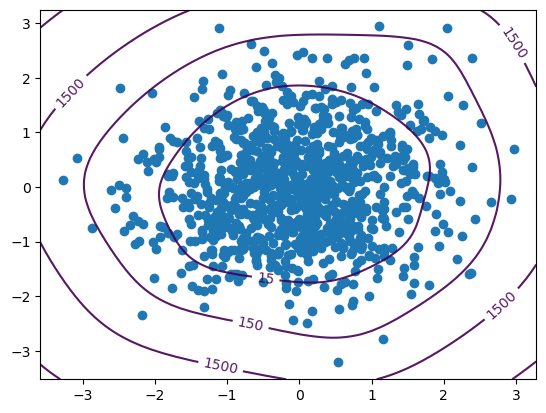

In [36]:
p = CDPolynomial(x, degree=d, verbose=True)
plt.scatter(*x.T)
p.plot(plt.gca())

In [37]:
y = p(x)

In [38]:
pf.fit_transform(x).shape

(1000, 45)

In [39]:
lm = LinearRegression()
lm.fit(pf.fit_transform(x), y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
y_pred = lm.predict(pf.fit_transform(x))

In [9]:
np.linalg.norm(y - y_pred)

0.0001319582382218985

In [10]:
y_pred.max()

484.6336337879306

In [11]:
y.max()

484.63364

In [12]:
lm.coef_

array([ 1.04763577e-11,  4.63566637e-01,  5.52913129e-01, -3.73399940e-01,
        6.52831308e-01, -3.30051716e-01, -7.73132264e-01, -2.01134453e+00,
        5.07942465e-01, -1.23131189e+00,  1.81105847e+00, -2.40907281e-01,
        5.93707147e+00, -1.89728658e+00,  2.63458525e+00,  5.39993600e-01,
        7.44853472e-01, -8.74908606e-01,  8.94647264e-01, -3.98505795e-03,
        7.94492372e-01, -4.66517883e-01, -6.37463381e-02, -1.86676151e+00,
        7.27954322e-01, -2.94060114e+00,  1.23209415e+00, -8.64915073e-01,
       -9.29353000e-02, -1.11146390e-01,  1.72280631e-01, -5.23997126e-02,
        2.42331808e-01, -2.39913535e-01, -5.99334601e-03, -1.31928420e-01,
        5.80411134e-02,  1.76711434e-02,  2.41241956e-01, -3.84161487e-02,
        5.82170285e-01, -2.03548438e-01,  5.72917570e-01, -2.06221678e-01,
        1.15538149e-01])

In [41]:
npz = np.load('../benchmark/half_cheetah/train.npz')

In [42]:
sa = npz['sa']

In [43]:
sa.shape

(50000, 23)

In [44]:
d = 1
p = CDPolynomial(sa, degree=d, verbose=True)
y = p(sa)

Data monomials shape: torch.Size([50000, 24])
Moment matrix cond num: 2.258469e+04
Empirical mean of CD poly: 23.999998092651367


In [61]:
pf = PolynomialFeatures(degree = 2*d)
v = pf.fit_transform(sa)
v.shape

(50000, 300)

In [62]:
lm = Lasso().fit(v, y)

In [63]:
y_pred = lm.predict(v)

In [64]:
y_pred.min()

0.7129700445808602

In [65]:
y.min()

2.0363486

In [70]:
(lm.coef_ > 0).mean()

0.17666666666666667

In [73]:
lm.coef_.max()

7.281594879480629

(array([4.2484e+04, 5.4350e+03, 1.3190e+03, 5.3900e+02, 1.4500e+02,
        4.6000e+01, 1.9000e+01, 7.0000e+00, 2.0000e+00, 4.0000e+00]),
 array([  2.03634858,  46.20090866,  90.36547089, 134.5300293 ,
        178.69458008, 222.85914612, 267.02371216, 311.18826294,
        355.35281372, 399.51739502, 443.6819458 ]),
 <BarContainer object of 10 artists>)

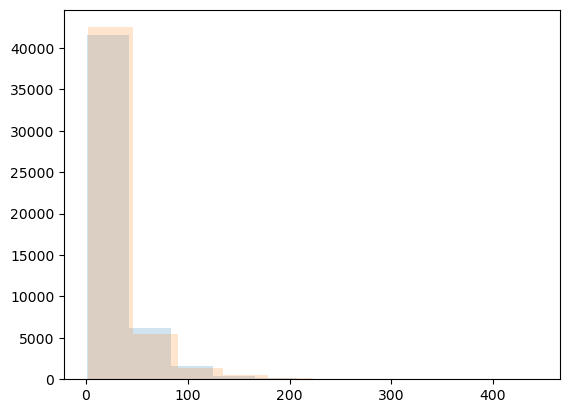

In [67]:
plt.hist(y_pred, alpha=.2)
plt.hist(y, alpha=.2)

In [24]:
(np.abs(lm.coef_) < 100).mean()

0.9966666666666667